# **Install Dependencies**

In [1]:
!pip install facenet-pytorch opencv-python-headless timm split-folders -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/

In [2]:
!pip install -q "numpy==1.26.4" --force-reinstall

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which

In [3]:
!pip install -q "numpy==1.26.4" datasets pillow

# **Import Modules**

In [1]:
import random
import shutil
import os
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
import kagglehub
import cv2
import splitfolders
import timm
import torch.nn as nn

from datasets import load_dataset
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# **Download Dataset**

In [2]:
DATASET_PATH = kagglehub.dataset_download("axondata/face-anti-spoofing-dataset")

print("Path to dataset files:", DATASET_PATH)

100%|██████████| 4.94G/4.94G [03:55<00:00, 22.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/axondata/face-anti-spoofing-dataset/versions/1


In [3]:
OUTPUT_LIVE_DIR = "./output/live"
TARGET_N        = 3500

os.makedirs(OUTPUT_LIVE_DIR, exist_ok=True)

print("Loading dataset dari HuggingFace (streaming)...")
ds = load_dataset(
    "nguyenkhoa/celeba-spoof-for-face-antispoofing-test",
    split="test",
    streaming=True
)

Loading dataset dari HuggingFace (streaming)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/437 [00:00<?, ?B/s]

In [4]:
saved = 0

for sample in ds:
    if sample["labels"] == 0:
        img: Image.Image = sample["cropped_image"]
        out_path = os.path.join(OUTPUT_LIVE_DIR, f"celeba_live_{saved:05d}.jpg")

        if img is None:
            continue

        img.save(out_path)
        saved += 1
        if saved % 200 == 0:
            print(f"  Saved {saved}/{TARGET_N} live images...")
        if saved >= TARGET_N:
            break

print(f"Selesai. {saved} live images disimpan ke {OUTPUT_LIVE_DIR}")

  Saved 200/3500 live images...
  Saved 400/3500 live images...
  Saved 600/3500 live images...
  Saved 800/3500 live images...
  Saved 1000/3500 live images...
  Saved 1200/3500 live images...
  Saved 1400/3500 live images...
  Saved 1600/3500 live images...
  Saved 1800/3500 live images...
  Saved 2000/3500 live images...
  Saved 2200/3500 live images...
  Saved 2400/3500 live images...
  Saved 2600/3500 live images...
  Saved 2800/3500 live images...
  Saved 3000/3500 live images...
  Saved 3200/3500 live images...
  Saved 3400/3500 live images...
Selesai. 3500 live images disimpan ke ./output/live


# **Extract Dataset**

In [5]:
VIDEO_EXTENSIONS = (".mp4", ".mov", ".MOV", ".MP4", ".avi", ".AVI")
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

OUTPUT_ROOT  = "./output"

FOLDER_LABEL = {
    "Selfies" : 0,
    "3D_paper_mask " : 1,
    "Cutout_attacks" : 1,
    "Latex_mask" : 1,
    "Replay_mobile_attacks" : 1,
    "Silicone_mask" : 1,
    "Wrapped_3D_paper_mask" : 1,
    "Textile 3D Face Mask Attack Sample" : 1,
}

SUBFOLDER_LABEL = {
    "Replay_display_attacks/Real" : 0,
    "Replay_display_attacks/Screen" : 1,
}

In [6]:
class Extractor:

    def __init__(
        self,
        dataset_path,
        output_root,
        folder_label,
        subfolder_label,
        frame_interval=10,
    ):
        self.dataset_path    = dataset_path
        self.output_root     = output_root
        self.folder_label    = folder_label
        self.subfolder_label = subfolder_label
        self.frame_interval  = frame_interval

    def build(self):
        for folder, label in self.folder_label.items():
            folder_path = os.path.join(self.dataset_path, folder)
            if not os.path.exists(folder_path):
                print(f"[SKIP] Folder tidak ditemukan: {folder_path}")
                continue
            self._process_folder(folder_path, label, source_name=folder)

        for rel_path, label in self.subfolder_label.items():
            folder_path = os.path.join(self.dataset_path, rel_path)
            if not os.path.exists(folder_path):
                print(f"[SKIP] Subfolder tidak ditemukan: {folder_path}")
                continue
            source_name = rel_path.replace("/", " → ")
            self._process_folder(folder_path, label, source_name=source_name)

    # private
    def _process_folder(self, folder_path, label, source_name):
        label_name = "live" if label == 0 else "spoof"
        output_dir = os.path.join(self.output_root, label_name)
        os.makedirs(output_dir, exist_ok=True)

        all_files = self._crawl(folder_path)
        videos    = [f for f in all_files if f.lower().endswith(VIDEO_EXTENSIONS)]
        images    = [f for f in all_files if f.lower().endswith(IMAGE_EXTENSIONS)]

        print(f"\n[{label_name.upper()}] {source_name} → {len(videos)} videos, {len(images)} images")

        for path in tqdm(videos, desc="  Extracting frames"):
            self._extract_frames(path, output_dir)

        for path in tqdm(images, desc="  Copying images"):
            self._copy_image(path, output_dir)

    def _crawl(self, folder_path):
        """Rekursif cari semua file video & gambar dalam folder."""
        found = []
        for entry in os.listdir(folder_path):
            full_path = os.path.join(folder_path, entry)
            if os.path.isdir(full_path):
                found += self._crawl(full_path)
            elif entry.lower().endswith(VIDEO_EXTENSIONS + IMAGE_EXTENSIONS):
                found.append(full_path)
        return found

    def _extract_frames(self, video_path, output_dir):
        """Ambil frame dari video setiap N frame, simpan sebagai jpg."""
        cap         = cv2.VideoCapture(video_path)
        video_name  = os.path.splitext(os.path.basename(video_path))[0]
        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_count % self.frame_interval == 0:
                out_path = os.path.join(output_dir, f"{video_name}_f{frame_count:05d}.jpg")
                cv2.imwrite(out_path, frame)
            frame_count += 1

        cap.release()

    def _copy_image(self, src_path, output_dir):
        """Copy gambar ke output_dir, hindari overwrite dengan rename jika perlu."""
        filename = os.path.basename(src_path)
        dst_path = os.path.join(output_dir, filename)

        if os.path.exists(dst_path):
            base, ext   = os.path.splitext(filename)
            parent_name = os.path.basename(os.path.dirname(src_path))
            filename    = f"{parent_name}_{base}{ext}"
            dst_path    = os.path.join(output_dir, filename)

        shutil.copy2(src_path, dst_path)

In [7]:
extract_photo = Extractor(
        dataset_path    = DATASET_PATH,
        output_root     = OUTPUT_ROOT,
        folder_label    = FOLDER_LABEL,
        subfolder_label = SUBFOLDER_LABEL,
        frame_interval  = 10,
    )

extract_photo.build()


[LIVE] Selfies → 0 videos, 25 images


  Extracting frames: 0it [00:00, ?it/s]
  Copying images: 100%|██████████| 25/25 [00:00<00:00, 884.64it/s]



[SPOOF] 3D_paper_mask  → 36 videos, 0 images


  Extracting frames: 100%|██████████| 36/36 [01:25<00:00,  2.37s/it]
  Copying images: 0it [00:00, ?it/s]



[SPOOF] Cutout_attacks → 15 videos, 0 images


...

  Extracting frames: 100%|██████████| 23/23 [05:17<00:00, 13.81s/it]
  Copying images: 0it [00:00, ?it/s]



[LIVE] Replay_display_attacks → Real → 0 videos, 5 images


  Extracting frames: 0it [00:00, ?it/s]
  Copying images: 100%|██████████| 5/5 [00:00<00:00, 452.00it/s]



[SPOOF] Replay_display_attacks → Screen → 5 videos, 0 images


  Extracting frames: 100%|██████████| 5/5 [00:34<00:00,  6.92s/it]
  Copying images: 0it [00:00, ?it/s]


# **Exploratory Data Analysis**

In [8]:
for split in ["live", "spoof"]:
    path = os.path.join(OUTPUT_ROOT, split)
    n    = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"{split:6s} : {n:>8,} files")

live_n  = len(os.listdir(os.path.join(OUTPUT_ROOT, "live")))
spoof_n = len(os.listdir(os.path.join(OUTPUT_ROOT, "spoof")))
total   = live_n + spoof_n
ratio   = spoof_n / live_n

print(f"\nTotal  : {total:,}")
print(f"Ratio  : {ratio:.2f}x (spoof/live)")

live   :    3,530 files
spoof  :    3,338 files

Total  : 6,868
Ratio  : 0.95x (spoof/live)


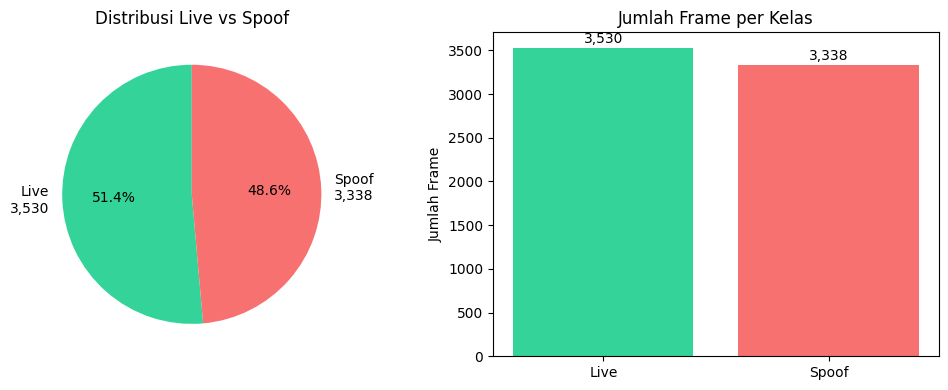

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie
axes[0].pie(
    [live_n, spoof_n],
    labels=[f"Live\n{live_n:,}", f"Spoof\n{spoof_n:,}"],
    colors=["#34d399", "#f87171"],
    autopct="%1.1f%%", startangle=90,
)
axes[0].set_title("Distribusi Live vs Spoof")

# Bar
axes[1].bar(["Live", "Spoof"], [live_n, spoof_n], color=["#34d399", "#f87171"])
axes[1].set_ylabel("Jumlah Frame")
axes[1].set_title("Jumlah Frame per Kelas")
for i, v in enumerate([live_n, spoof_n]):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

# **Train Test Split**

In [10]:
splitfolders.ratio(
    input = "./output",
    output = "./split",
    seed=42,
    ratio= (0.70, 0.15, 0.15)
)

Copying files: 6868 files [00:29, 230.63 files/s]


# **Data Augmentation**

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),

    # Rotation
    transforms.RandomChoice([
        transforms.RandomRotation(degrees=(0, 0)),
        transforms.RandomRotation(degrees=(90, 90)),
        transforms.RandomRotation(degrees=(180, 180)),
        transforms.RandomRotation(degrees=(270, 270)),
    ]),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomGrayscale(p=0.05),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),

])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [12]:
class LivenessDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        """
        root_dir : path ke folder yang berisi subfolder 'live' dan 'spoof'
        """
        self.transform = transform
        self.samples = []

        self.class_map = {"live": 0, "spoof": 1}

        for class_name, label in self.class_map.items():
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append((os.path.join(class_dir, fname), label))

        print(f"Dataset loaded: {len(self.samples)} samples")
        live_n = sum(1 for _, l in self.samples if l == 0)
        spoof_n = sum(1 for _, l in self.samples if l == 1)
        print(f"live : {live_n:,} | spoof : {spoof_n:,}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

In [13]:
train_dataset = LivenessDataset("./split/train", transform=train_transform)
val_dataset   = LivenessDataset("./split/val",   transform=val_transform)
test_dataset  = LivenessDataset("./split/test",  transform=val_transform)

Dataset loaded: 4807 samples
live : 2,471 | spoof : 2,336
Dataset loaded: 1029 samples
live : 529 | spoof : 500
Dataset loaded: 1032 samples
live : 530 | spoof : 502


In [14]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# **Model Development**

In [15]:
class LivenessModel(nn.Module):

  def __init__(self, pretrained=True):
    super().__init__()

    self.backbone = timm.create_model(
        "efficientnet_b0",
        pretrained=pretrained,
        num_classes=0,
    )

    in_features = self.backbone.num_features

    self.head = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, 1),
    )

  def forward(self, x):
    features = self.backbone(x)
    output = self.head(features)

    return output.squeeze(1)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = LivenessModel(pretrained=True).to(device)

Device: cuda


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [17]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=1e-6,
)

# **Training Model**

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):

  model.train()
  total_loss, correct, total = 0, 0, 0

  for imgs, labels in loader:
    imgs = imgs.to(device)
    labels = labels.float().to(device)

    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item() * imgs.size(0)
    preds = (torch.sigmoid(outputs) >= 0.5).long()
    correct += (preds == labels.long()).sum().item()
    total += imgs.size(0)

  return total_loss / total, correct / total

In [19]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.float().to(device)

            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            preds       = (torch.sigmoid(outputs) >= 0.5).long()
            correct    += (preds == labels.long()).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total

In [21]:
NUM_EPOCHS  = 2
SAVE_PATH   = "./best_model.pth"

best_val_acc = 0.0
history      = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        saved = "saved"
    else:
        saved = ""

    elapsed = time.time() - start
    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
        f"| train loss: {train_loss:.4f} acc: {train_acc:.4f} "
        f"| val loss: {val_loss:.4f} acc: {val_acc:.4f} "
        f"| {elapsed:.1f}s {saved}"
    )

print(f"\n✅ Training selesai. Best val acc: {best_val_acc:.4f}")

Epoch [01/2] | train loss: 0.0043 acc: 0.9992 | val loss: 0.0073 acc: 0.9971 | 205.0s saved
Epoch [02/2] | train loss: 0.0019 acc: 0.9994 | val loss: 0.0040 acc: 0.9990 | 207.2s saved

✅ Training selesai. Best val acc: 0.9990


# **Test Data**

In [22]:
val_test, acc_test = evaluate(model, test_loader, criterion, device)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [25]:
print(f"Test Loss: {val_test:.4f}")
print(f"Test Accuracy: {acc_test:.4f}")

Test Loss: 0.0004
Test Accuracy: 1.0000
